In [1]:
import os
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset
from torchvision.io import decode_image
from torchvision.transforms import v2

class ImageDataset:
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.transform = v2.Compose([
            v2.Resize((256, 256)),
            v2.ToDtype(torch.float32, scale=True)
        ])
        self.img = list(Path(self.root_dir).rglob("*.png"))

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        image = decode_image(self.img[idx])
        if self.transform:
            image = self.transform(image)
        return image


In [5]:
from torch import nn
import torch
from torch.utils.data import DataLoader

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # → (32, 128, 128)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # → (64, 64, 64)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# → (128, 32, 32)
            nn.ReLU(),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 128 * 32 * 32),
            nn.Unflatten(1, (128, 32, 32))
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # → (64, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # → (32, 128, 128)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),   # → (3, 256, 256)
            nn.Sigmoid()  # pixels entre 0 et 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.fc(x)
        x = self.decoder(x)
        return x


In [6]:
import gc
device = 'cuda' if torch.cuda.is_available() else'cpu'

def train_loop(dataloader, model, loss_fn, optimizer, batch_size):
    size = len(dataloader.dataset)
    model.to(device)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    train_loss = 0
    num_batches = len(dataloader)

    for batch, X in enumerate(dataloader):
        X = X.to(device)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, X)
        train_loss += loss.item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Train loss : {train_loss/num_batches}")
    # À la fin de chaque epoch ou du training
    torch.cuda.empty_cache()
    gc.collect()

def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.to(device)
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X in dataloader:
            X = X.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, X).item()

    test_loss /= num_batches
    return test_loss


In [7]:
model = ConvAutoencoder()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

print("Importing data...")

training_data = ImageDataset("/content/drive/MyDrive/mvtec-dataset/bottle/bottle/train")

batch_size = 32
epochs = 50

train_dataloader = DataLoader(training_data, batch_size=batch_size)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer, batch_size)

Importing data...
Epoch 1
-------------------------------
Train loss : 0.09506514508809362
Epoch 2
-------------------------------
Train loss : 0.017615415155887604
Epoch 3
-------------------------------
Train loss : 0.007148615683295897
Epoch 4
-------------------------------
Train loss : 0.00450906390324235
Epoch 5
-------------------------------
Train loss : 0.0034695970493235757
Epoch 6
-------------------------------
Train loss : 0.003069704697866525
Epoch 7
-------------------------------
Train loss : 0.0027430423069745302
Epoch 8
-------------------------------
Train loss : 0.002556062236960445
Epoch 9
-------------------------------
Train loss : 0.002460524406550186
Epoch 10
-------------------------------
Train loss : 0.0023764491280806915
Epoch 11
-------------------------------
Train loss : 0.0023031800852290223
Epoch 12
-------------------------------
Train loss : 0.002253254276833364
Epoch 13
-------------------------------
Train loss : 0.00221800385043025
Epoch 14
------

In [10]:
DIR_PATH = "/content/drive/MyDrive/mvtec-dataset/bottle/bottle/test/"
loss_fun = nn.MSELoss(reduction='none')

results = {
    'good': [],
    'broken_small': [],
    'broken_large': [],
    'contamination': []
}

datasets = {
    'good': None,
    'broken_small': None,
    'broken_large': None,
    'contamination': None
}

for dir in results.keys():
  datasets[dir] = ImageDataset(DIR_PATH + dir)
  dataloader = DataLoader(datasets[dir], batch_size=1000)
  for X in dataloader:
    X = X.to(device)
    pred = model(X)
    loss = loss_fun(pred, X)
    if device == 'cuda':
      results[dir] = loss.mean(dim=(1,2,3)).cpu().detach().numpy()
    else:
      results[dir] = loss.mean(dim=(1,2,3)).detach().numpy() #mean for each image


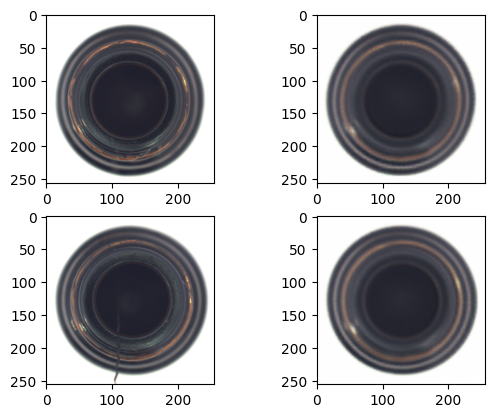

In [11]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    img_good = datasets['good'][0].to(device)      # une image good du test
    img_broken = datasets['contamination'][0].to(device)    # une image broken

    rec_good = model(img_good.unsqueeze(0))
    rec_broken = model(img_broken.unsqueeze(0))

    img_good = img_good.cpu()
    img_broken = img_broken.cpu()
    rec_good = rec_good.cpu()
    rec_broken = rec_broken.cpu()

fig, axes = plt.subplots(2, 2)
axes[0,0].imshow(img_good.permute(1,2,0))
axes[0,1].imshow(rec_good.squeeze().permute(1,2,0))
axes[1,0].imshow(img_broken.permute(1,2,0))
axes[1,1].imshow(rec_broken.squeeze().permute(1,2,0))
plt.show()

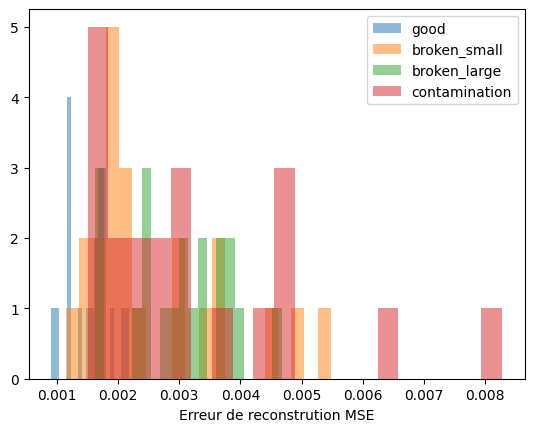

In [12]:
for state, error in results.items():
  plt.hist(error, alpha=0.5, label=state, bins=20)

plt.xlabel('Erreur de reconstrution MSE')
plt.legend()
plt.show()

In [13]:
results

{'good': array([0.00168427, 0.00179296, 0.00122069, 0.00191471, 0.00156977,
        0.00090654, 0.00148533, 0.00169253, 0.0011895 , 0.00166718,
        0.00167566, 0.00122213, 0.00141027, 0.00117222, 0.00099823,
        0.00205617, 0.0016444 , 0.00179561, 0.00176628, 0.00218071],
       dtype=float32),
 'broken_small': array([0.00115349, 0.00157736, 0.00206228, 0.00209973, 0.00350624,
        0.00354951, 0.00140824, 0.00162184, 0.00196326, 0.00221457,
        0.00495858, 0.00196086, 0.00304633, 0.00187107, 0.00547716,
        0.00163446, 0.00188876, 0.00288576, 0.00180445, 0.00361489,
        0.00453857, 0.00224371], dtype=float32),
 'broken_large': array([0.00162495, 0.00378565, 0.00400711, 0.00305296, 0.00375384,
        0.00467445, 0.00247827, 0.00306293, 0.00387083, 0.0029892 ,
        0.00177175, 0.00315983, 0.0024944 , 0.0033464 , 0.00236233,
        0.00245776, 0.00338375, 0.00364645, 0.00173952, 0.00272285],
       dtype=float32),
 'contamination': array([0.00179323, 0.0027347 